In [2]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import pyarrow.dataset as ds
import pyarrow.fs as fs

from pathlib import Path

print("success!")

success!


In [1]:
import sys
print(sys.executable)

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/bin/python


In [4]:
# =========================
# 1. settings
# =========================

FOCAL_SITES = ["HARV"]
MY_MODEL_ID = "XGBoost"
N_REP = 1

features = [
    "air_temperature",
    "eastward_wind",
    "surface_downwelling_shortwave_flux_in_air",
    "precipitation_flux",
    "relative_humidity",
    "northward_wind",
    "surface_downwelling_longwave_flux_in_air",
    "air_pressure",
    "latitude",
    "longitude",
    "field_mean_elevation_m"]


# =========================
# 2. load data
# =========================

def load_targets():
    targets = pd.read_csv("terrestrial_daily_targets.csv")
    targets["datetime"] = pd.to_datetime(targets["datetime"]).dt.tz_localize(None)
    targets = targets.loc[
        targets["site_id"].isin(FOCAL_SITES) & (targets["variable"] == "nee"),
        ["datetime", "site_id", "observation"]
    ].rename(columns={"observation": "nee"})
    return targets


def load_weather_past(filepath="weather_past_daily_HARV.csv"):
    df = pd.read_csv(filepath)
    df["datetime"] = pd.to_datetime(df["datetime"]).dt.tz_localize(None)
    return df


def load_weather_future(filepath="weather_future_daily_HARV.csv"):
    df = pd.read_csv(filepath)
    df["datetime"] = pd.to_datetime(df["datetime"]).dt.tz_localize(None)
    df["reforecast_date"] = pd.to_datetime(df["reforecast_date"]).dt.tz_localize(None)
    if "noaa_date" in df.columns:
        df["noaa_date"] = pd.to_datetime(df["noaa_date"]).dt.tz_localize(None)
    return df

def cal_vpd(temp_c, rh):
    """
    mp_c: air temperature in Celsius
    rh: relative humidity, can be 0-1 or 0-100
    returns VPD in kPa
    """
    rh = np.asarray(rh, dtype=float) * 100
    temp_c = np.asarray(temp_c, dtype=float)

    es = 0.6108 * np.exp((17.27 * temp_c) / (temp_c + 237.3))
    ea = es * rh / 100
    vpd = es - ea

    return np.maximum(vpd, 0)
    
        
# =========================
# 3. feature engineering
# =========================

def add_features(df):
    df = df.sort_values(["site_id", "datetime"]).copy()

    df["nee_lag1"] = df.groupby("site_id")["nee"].shift(1)
    df["nee_7day_mean"] = (df.groupby("site_id")["nee"].transform(lambda s: s.shift(1).rolling(window=7, min_periods=7).mean()))

    df["prcp_30days"] = (
        df.groupby("site_id")["precipitation_flux"]
        # .transform(lambda s: s.rolling(window=30, min_periods=30).mean())
        .transform(lambda s: s.shift(1).rolling(window=7, min_periods=1).sum()))
    df["temp_x_shortwave"] = df["air_temperature"] * df["surface_downwelling_shortwave_flux_in_air"]
    
    # df["DOY"] = df["datetime"].dt.dayofyear
    df["doy_sin"] = np.sin(2*np.pi*df["datetime"].dt.dayofyear/365.25)
    df["doy_cos"] = np.cos(2*np.pi*df["datetime"].dt.dayofyear/365.25)

    df["vpd"] = cal_vpd(df["air_temperature"], df["relative_humidity"])
    return df


def prepare_training_data(targets, weather_past):
    df = targets.merge(weather_past, on=["datetime", "site_id"], how="left")
    df = add_features(df)
    return df


# =========================
# 4. model training
# =========================

FEATURE_COLS = [
    "nee_lag1",
    "nee_7day_mean",
    "air_temperature",
    "eastward_wind",
    "surface_downwelling_shortwave_flux_in_air",
    # "DOY",
    "doy_sin",
    "doy_cos",
    "vpd",
    "precipitation_flux",
    "relative_humidity",
    "northward_wind",
    "surface_downwelling_longwave_flux_in_air",
    "air_pressure",
    "latitude",
    "longitude",
    "field_mean_elevation_m",
    "prcp_30days",
    "temp_x_shortwave"
]


def train_xgb_model(train_df):
    train_df = train_df.dropna(subset=["nee"] + FEATURE_COLS).copy()

    X_train = train_df[FEATURE_COLS].to_numpy()
    y_train = train_df["nee"].to_numpy()

    dtrain = xgb.DMatrix(X_train, label=y_train)

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "eta": 0.05,
        "max_depth": 4,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    }

    cv_fit = xgb.cv(
        params=params,
        dtrain=dtrain,
        num_boost_round=100,
        nfold=5,
        early_stopping_rounds=10,
        verbose_eval=False
    )

    best_nrounds = len(cv_fit) if len(cv_fit) > 0 else 100

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=best_nrounds,
        verbose_eval=False
    )

    train_pred = model.predict(dtrain)
    sigma_resid = np.nanstd(y_train - train_pred)
    if np.isnan(sigma_resid) or sigma_resid == 0:
        sigma_resid = 0.01

    return model, sigma_resid


# =========================
# 5. recursive forecast
# =========================

def make_member_driver_map(driver_ids, n_rep=10):
    return pd.DataFrame({
        "member_id": np.arange(1, len(driver_ids) * n_rep + 1),
        "driver_parameter": np.repeat(driver_ids, n_rep),
        "rep_id": np.tile(np.arange(1, n_rep + 1), len(driver_ids))
    })


def recursive_forecast_for_site(model, sigma_resid, site_target, future_site, forecast_date):
    forecast_outputs = []
    driver_ids = sorted(future_site["parameter"].dropna().unique())
    if len(driver_ids) == 0:
        return pd.DataFrame()

    member_driver_map = make_member_driver_map(driver_ids, n_rep=N_REP)
    last_nee = (site_target.sort_values("datetime").iloc[-1]["nee"])
    init_df = member_driver_map[["member_id"]].copy()
    init_df["init_nee"] = np.random.normal(loc=last_nee, scale=sigma_resid, size=len(init_df))

    for _, row_map in member_driver_map.iterrows():
        member_id = int(row_map["member_id"])
        current_driver = row_map["driver_parameter"]

        future_j = (
            future_site.loc[future_site["parameter"] == current_driver]
            .sort_values("datetime")
            .copy()
        )

        if future_j.empty:
            continue

        nee_hist = (
            site_target.sort_values("datetime")
            .tail(30)["nee"]
            .to_numpy()
        )
        if len(nee_hist) < 30:
            continue
        prcp_hist = (site_target.sort_values("datetime").tail(14)["precipitation_flux"].to_numpy())
        if len(prcp_hist) < 14:
            continue

        init_nee_member = init_df.loc[init_df["member_id"] == member_id, "init_nee"].iloc[0]
        nee_hist[-1] = init_nee_member

        preds = []

        for _, row in future_j.iterrows():
            # current_air_temp = row["air_temperature"]
            # air_temp_window = np.concatenate([prcp_hist, [current_air_temp]])
            prcp_30days = np.sum(prcp_hist[-7:])
            current_vpd = cal_vpd(row["air_temperature"], row["relative_humidity"])

            nee_lag1 = nee_hist[-1]       # past 1-day lag; 0, 30-day lag
            nee_7day_mean = np.mean(nee_hist[-7:]) # mean in the past 7-days
            
            current_doy = row["datetime"].dayofyear
            doy_sin = np.sin(2 * np.pi * current_doy / 365.25)
            doy_cos = np.cos(2 * np.pi * current_doy / 365.25)
            temp_x_shortwave = row["air_temperature"] * row["surface_downwelling_shortwave_flux_in_air"]
            x_new = pd.DataFrame([{
                "nee_lag1": nee_lag1,
                "nee_7day_mean": nee_7day_mean,
                "air_temperature": row["air_temperature"],
                "eastward_wind": row["eastward_wind"],
                "surface_downwelling_shortwave_flux_in_air": row["surface_downwelling_shortwave_flux_in_air"],
                # "DOY": current_doy,
                "vpd": current_vpd,
                "doy_sin": doy_sin,
                "doy_cos": doy_cos,
                "precipitation_flux": row["precipitation_flux"],
                "relative_humidity": row["relative_humidity"],
                "northward_wind": row["northward_wind"],
                "surface_downwelling_longwave_flux_in_air": row["surface_downwelling_longwave_flux_in_air"],
                "air_pressure": row["air_pressure"],
                "latitude": row["latitude"],
                "longitude":row["longitude"],
                "field_mean_elevation_m": row["field_mean_elevation_m"],
                "prcp_30days": prcp_30days,
                "temp_x_shortwave": temp_x_shortwave
            }])

            pred_mean = model.predict(xgb.DMatrix(x_new[FEATURE_COLS].to_numpy()))[0]
            pred_val = float(pred_mean + np.random.normal(loc=0, scale=sigma_resid))

            preds.append(pred_val)

            nee_hist = np.concatenate([nee_hist[1:], [pred_val]])
            prcp_hist = np.concatenate([prcp_hist[1:], [row["precipitation_flux"]]])
            # air_temp_hist = air_temp_window[-6:]

        out = future_j[["datetime", "site_id"]].copy()
        out["reference_datetime"] = forecast_date
        out["duration"] = "P1D"
        out["family"] = "ensemble"
        out["parameter"] = str(member_id)
        out["variable"] = "nee"
        out["prediction"] = preds
        out["model_id"] = MY_MODEL_ID
        out["project_id"] = "neon4cast"

        forecast_outputs.append(out)

    if not forecast_outputs:
        return pd.DataFrame()

    return pd.concat(forecast_outputs, ignore_index=True)


def forecast_one_reforecast_date(forecast_date, train_base, weather_future_all):
    forecast_date = pd.Timestamp(forecast_date)

    all_site_outputs = []

    for site_id in FOCAL_SITES:
        site_train = (
            train_base.loc[
                (train_base["site_id"] == site_id) &
                (train_base["datetime"] < forecast_date)
            ]
            .sort_values("datetime")
            .copy()
        )

        site_train = site_train.dropna(subset=["nee"] + FEATURE_COLS)

        if len(site_train) < 30:
            print(f"{site_id}: skipped, too few training rows before {forecast_date.date()}")
            continue

        future_site = (
            weather_future_all[
                (weather_future_all["site_id"] == site_id) &
                (weather_future_all["reforecast_date"] == forecast_date) &
                (weather_future_all["datetime"] >= forecast_date)
            ]
            .sort_values(["parameter", "datetime"])
            .copy()
        )

        if future_site.empty:
            print(f"{site_id}: skipped, no future drivers for {forecast_date.date()}")
            continue

        model, sigma_resid = train_xgb_model(site_train)
        pred_df = recursive_forecast_for_site(
            model=model,
            sigma_resid=sigma_resid,
            site_target=site_train,
            future_site=future_site,
            forecast_date=forecast_date
        )

        if not pred_df.empty:
            all_site_outputs.append(pred_df)
            print(f"{site_id}: finished reforecast for {forecast_date.date()}")

    if not all_site_outputs:
        return pd.DataFrame()
    return pd.concat(all_site_outputs, ignore_index=True)

targets = load_targets()

weather_past = load_weather_past("weather_past_daily_HARV.csv")
weather_future_all = load_weather_future("weather_future_daily_HARV.csv")

# add site elevation and LAT/LON into the feature sets
site_summary = pd.read_csv("site_metadata.csv")
site_summary = site_summary.rename(columns={'field_site_id': 'site_id'})
site_summary = site_summary[site_summary["site_id"] == "HARV"]        # field_mean_elevation_m, latitude, longitude
weather_past = weather_past.merge(site_summary[["site_id", "field_mean_elevation_m", "latitude", "longitude"]], on=["site_id"], how="inner")
weather_future_all = weather_future_all.merge(site_summary[["site_id", "field_mean_elevation_m", "latitude", "longitude"]], on=["site_id"], how="inner")


train_base = prepare_training_data(targets, weather_past)

reforecast_dates = sorted(weather_future_all["reforecast_date"].dropna().unique())
# start_date = pd.Timestamp("2024-01-01")
# end_date = pd.Timestamp("2024-01-31")
# reforecast_dates = sorted(
# weather_future_all.loc[(weather_future_all["reforecast_date"] >= start_date) & (weather_future_all["reforecast_date"] <= end_date), "reforecast_date"].dropna().unique())

all_forecasts = []
for forecast_date in reforecast_dates:
    print(f"Running reforecast for {pd.Timestamp(forecast_date).date()}")
    result = forecast_one_reforecast_date(
        forecast_date=forecast_date,
        train_base=train_base,
        weather_future_all=weather_future_all)
    if not result.empty:
        all_forecasts.append(result)

if all_forecasts:
    reforecast_df = pd.concat(all_forecasts, ignore_index=True)
else:
    reforecast_df = pd.DataFrame(columns=[
        "datetime", "reference_datetime", "duration", "site_id",
        "family", "parameter", "variable", "prediction", "model_id", "project_id"])

reforecast_df_efi = reforecast_df.copy()

reforecast_df_efi.to_csv("reforecast_df_EFI_python_Jan_prcplag_TR.csv", index=False)
print("Saved to reforecast_df_EFI_python_Jan_prcplag_TR.csv")

Running reforecast for 2024-01-01
HARV: finished reforecast for 2024-01-01
Running reforecast for 2024-01-02
HARV: finished reforecast for 2024-01-02
Running reforecast for 2024-01-03
HARV: finished reforecast for 2024-01-03
Running reforecast for 2024-01-04
HARV: finished reforecast for 2024-01-04
Running reforecast for 2024-01-05
HARV: finished reforecast for 2024-01-05
Running reforecast for 2024-01-06
HARV: finished reforecast for 2024-01-06
Running reforecast for 2024-01-07
HARV: finished reforecast for 2024-01-07
Running reforecast for 2024-01-08
HARV: finished reforecast for 2024-01-08
Running reforecast for 2024-01-09
HARV: finished reforecast for 2024-01-09
Running reforecast for 2024-01-10
HARV: finished reforecast for 2024-01-10
Running reforecast for 2024-01-11
HARV: finished reforecast for 2024-01-11
Running reforecast for 2024-01-12
HARV: finished reforecast for 2024-01-12
Running reforecast for 2024-01-13
HARV: finished reforecast for 2024-01-13
Running reforecast for 20

In [2]:
weather_past = load_weather_past("weather_past_daily_HARV.csv")
weather_future_all = load_weather_future("weather_future_daily_HARV.csv")

# add site elevation and LAT/LON into the feature sets
site_summary = pd.read_csv("site_metadata.csv")
site_summary = site_summary.rename(columns={'field_site_id': 'site_id'})

site_summary = site_summary[site_summary["site_id"] == "HARV"]        # field_mean_elevation_m, latitude, longitude
weather_past = weather_past.merge(site_summary[["site_id", "field_mean_elevation_m", "latitude", "longitude"]], on=["site_id"], how="inner")
weather_future_all = weather_future_all.merge(site_summary[["site_id", "field_mean_elevation_m", "latitude", "longitude"]], on=["site_id"], how="inner")
weather_future_all

NameError: name 'load_weather_past' is not defined

In [5]:
model_summary = (
    reforecast_df_efi.groupby(['site_id', 'datetime'])['prediction'].agg(
        mean='mean',
        median='median',
        q02_5=lambda x: x.quantile(0.025),
        q10=lambda x: x.quantile(0.10),
        q90=lambda x: x.quantile(0.90),
        q97_5=lambda x: x.quantile(0.975)
    )
    .reset_index()
)

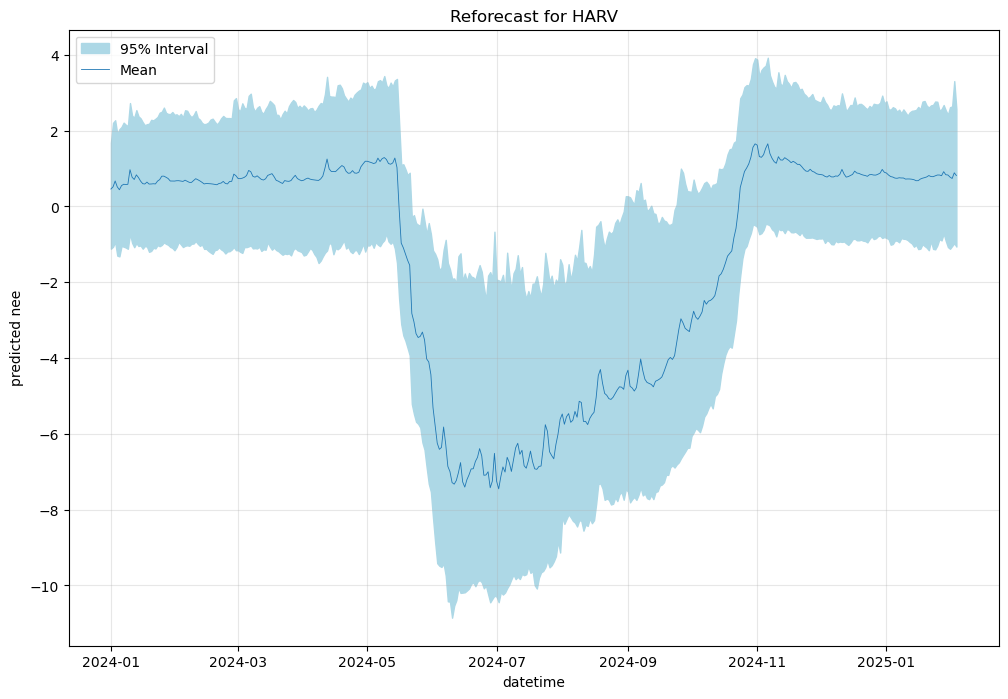

In [6]:
import matplotlib.pyplot as plt
plot_data = model_summary[model_summary['site_id'] == "HARV"]
plot_data['datetime'] = pd.to_datetime(plot_data['datetime'])

plt.figure(figsize=(12, 8))

plt.fill_between(
    plot_data['datetime'], 
    plot_data['q02_5'], 
    plot_data['q97_5'], 
    color='lightblue', 
    label='95% Interval'
)

plt.plot(
    plot_data['datetime'], 
    plot_data['mean'], 
    linewidth=0.6, 
    label='Mean'
)

plt.title("Reforecast for HARV")
plt.xlabel("datetime")
plt.ylabel("predicted nee")
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig("harv_reforecast_v2.png")
plt.show()

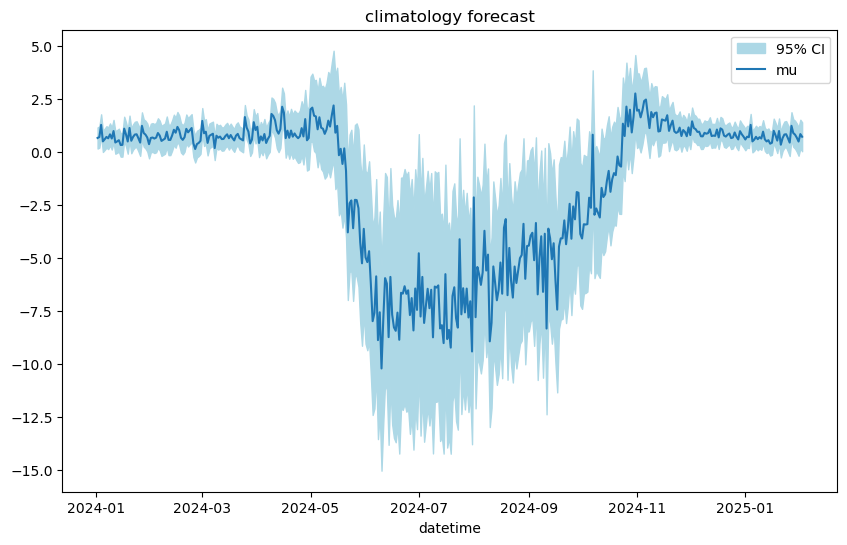

In [7]:
baseline_models = pd.read_csv("climatology_pred.csv")
climatology = baseline_models[(baseline_models["datetime"] >= "2024-01-02") &
                              (baseline_models["datetime"]<="2025-02-03") &
                              (baseline_models["model_id"] == 'climatology') &
                              (baseline_models["site_id"] == 'HARV')].copy()
df_pivot = climatology.pivot_table(index=['datetime', 'site_id', 'model_id'], columns='parameter', values='prediction').reset_index()
df_pivot['lower_2_5'] = df_pivot['mu'] - 1.96 * df_pivot['sigma']
df_pivot['upper_97_5'] = df_pivot['mu'] + 1.96 * df_pivot['sigma']
plt.figure(figsize=(10, 6))
df_pivot['datetime'] = pd.to_datetime(df_pivot['datetime'])
df_pivot = df_pivot.sort_values('datetime')
plt.fill_between(
    df_pivot['datetime'], 
    df_pivot['lower_2_5'], 
    df_pivot['upper_97_5'], 
    color='lightblue', 
    label='95% CI'
)
plt.plot(
    df_pivot['datetime'], 
    df_pivot['mu'], 
    label='mu'
)

plt.title("climatology forecast")
plt.xlabel("datetime")
plt.legend()
plt.show()

Reforecast dtype: datetime64[ns]
Targets dtype:    datetime64[ns]
Normal CLI dtype: datetime64[ns]


/localscratch/5135292/ipykernel_75250/2777655136.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({'crps': crps_tidy_ensemble(x)}))


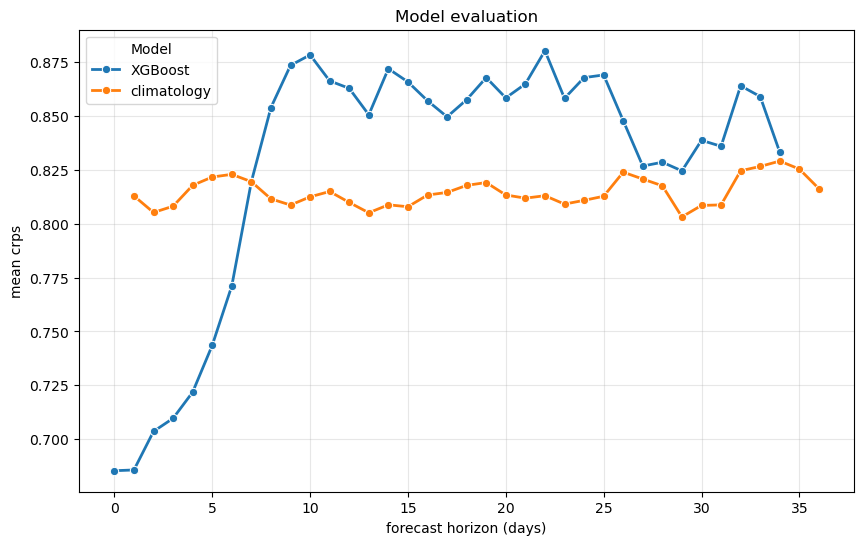

In [8]:

import properscoring as ps

targets = pd.read_csv("terrestrial_daily_targets.csv")

multi_forecast = (
    climatology[climatology['model_id'] == "climatology"]
    .merge(targets, on=['datetime', 'site_id', 'variable'], how='left')
)

multi_forecast = multi_forecast.dropna(subset=['observation'])
multi_forecast_summary = (
    multi_forecast
    .groupby(['model_id', 'site_id', 'reference_datetime', 'datetime', 'variable', 'observation', 'parameter'])['prediction']
    .mean()
    .reset_index())

df_pivot = multi_forecast_summary.pivot(
    index=['model_id', 'site_id', 'reference_datetime', 'datetime', 'variable', 'observation'],
    columns='parameter',
    values='prediction').reset_index()

df_pivot['reference_datetime'] = pd.to_datetime(df_pivot['reference_datetime'])
df_pivot['datetime'] = pd.to_datetime(df_pivot['datetime'])

df_pivot['horizon'] = (df_pivot['datetime'] - df_pivot['reference_datetime']).dt.days

df_pivot['crps'] = ps.crps_gaussian(
    df_pivot['observation'], 
    mu=df_pivot['mu'].astype(float), 
    sig=df_pivot['sigma'].astype(float)
)

multi_forecast_parametric_CLI = df_pivot
normal_crps_CLI = (
    multi_forecast_parametric_CLI
    .groupby(['datetime', 'reference_datetime', 'model_id'])['crps']
    .mean()
    .reset_index())

reforecast_df_efi['datetime'] = pd.to_datetime(reforecast_df_efi['datetime'])
targets['datetime'] = pd.to_datetime(targets['datetime']).dt.tz_localize(None)
normal_crps_CLI['datetime'] = pd.to_datetime(normal_crps_CLI['datetime']).dt.tz_localize(None)

print(f"Reforecast dtype: {reforecast_df_efi['datetime'].dtype}")
print(f"Targets dtype:    {targets['datetime'].dtype}")
print(f"Normal CLI dtype: {normal_crps_CLI['datetime'].dtype}")

import seaborn as sns
reforecast_df_efi['datetime'] = pd.to_datetime(reforecast_df_efi['datetime'])
multi_forecast_ensemble = (
    reforecast_df_efi[reforecast_df_efi['model_id'] == "XGBoost"]
    .merge(targets, on=['datetime', 'site_id', 'variable'], how='left')
    .dropna(subset=['observation'])
    [['model_id', 'datetime', 'prediction', 'observation', 'parameter', 'reference_datetime']]
)

def crps_tidy_ensemble(group):
    obs = group['observation'].iloc[0]
    return ps.crps_ensemble(obs, group['prediction'])

ensemble_crps = (
    multi_forecast_ensemble
    .groupby(['datetime', 'model_id', 'reference_datetime'])
    .apply(lambda x: pd.Series({'crps': crps_tidy_ensemble(x)}))
    .reset_index()
)


ensemble_crps['datetime'] = pd.to_datetime(ensemble_crps['datetime'])
ensemble_crps['reference_datetime'] = pd.to_datetime(ensemble_crps['reference_datetime'])
ensemble_crps['horizon'] = (ensemble_crps['datetime'] - ensemble_crps['reference_datetime']).dt.days
crps_all = pd.concat([ensemble_crps, normal_crps_CLI], axis=0, ignore_index=True)

crps_all['reference_datetime'] = pd.to_datetime(crps_all['reference_datetime'], utc=True)
crps_all['datetime'] = pd.to_datetime(crps_all['datetime'], utc=True)
crps_all['horizon'] = (crps_all['datetime'] - crps_all['reference_datetime']).dt.days

plot_df = (
    crps_all
    .groupby(['model_id', 'horizon'])['crps']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x='horizon', y='crps', hue='model_id', marker='o', linewidth=2)

plt.title("Model evaluation")
plt.xlabel("forecast horizon (days)")
plt.ylabel("mean crps")
plt.legend(title="Model")
plt.grid(True, alpha=0.3)
# plt.savefig("crps_v2.png")
plt.show()

/apps/common/software/Miniforge3/25.11.0-1-jupyter-base/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/localscratch/5135292/ipykernel_75250/2476357871.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap)


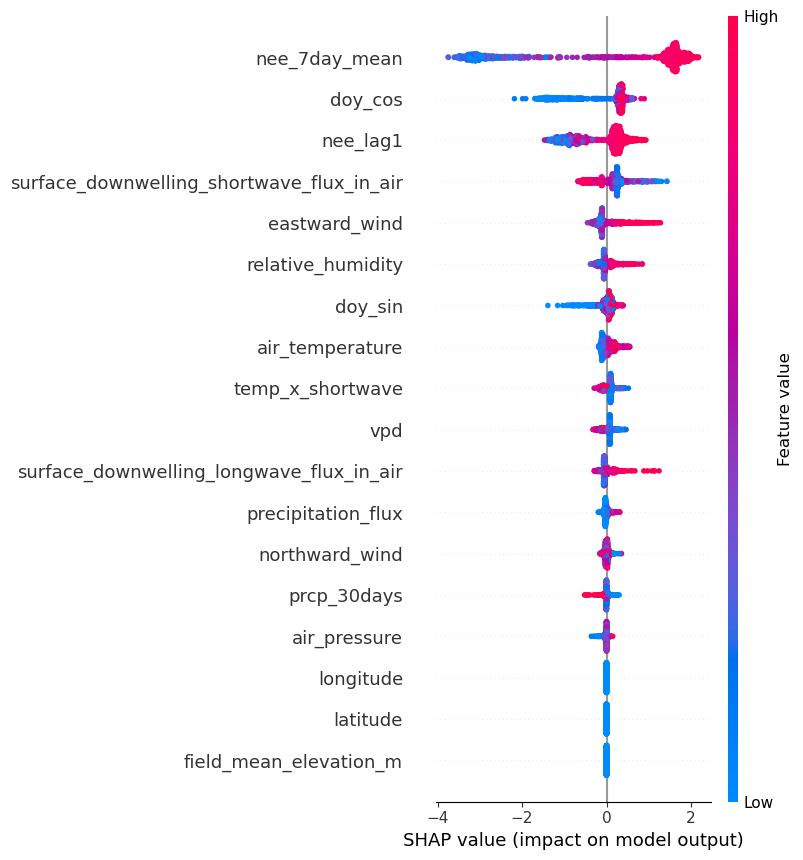

/localscratch/5135292/ipykernel_75250/2476357871.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, plot_type="bar")


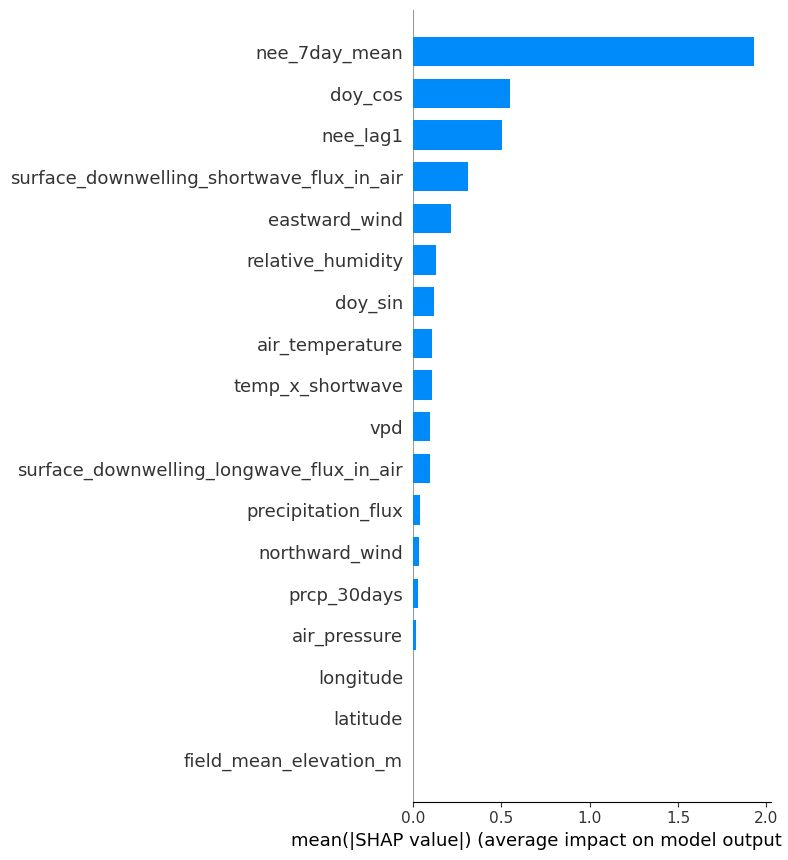

In [9]:
import shap
import matplotlib.pyplot as plt
forecast_date = pd.Timestamp("2024-07-20")

site_train = (
            train_base.loc[
                (train_base["site_id"] == "HARV") &
                (train_base["datetime"] < forecast_date)
            ]
            .sort_values("datetime")
            .copy()
        )

site_train = site_train.dropna(subset=["nee"] + FEATURE_COLS)

model, sigma_resid = train_xgb_model(site_train)

X_shap = site_train.dropna(subset=["nee"] + FEATURE_COLS)[FEATURE_COLS]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(shap_values, X_shap)
shap.summary_plot(shap_values, X_shap, plot_type="bar")